In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from keras import layers, Model
from keras.datasets import cifar10

# 1. Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# 2. Preprocessing: Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# y labels are shape (50000, 1), flatten them to (50000,)
y_train = y_train.flatten()
y_test = y_test.flatten()

print(f"x_train shape: {x_train.shape} - y_train shape: {y_train.shape}")
print(f"x_test shape:  {x_test.shape} - y_test shape:  {y_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
x_train shape: (50000, 32, 32, 3) - y_train shape: (50000,)
x_test shape:  (10000, 32, 32, 3) - y_test shape:  (10000,)


In [2]:
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score

# Flatten images: (32, 32, 3) -> 3072
x_train_flat = x_train.reshape(len(x_train), -1)
x_test_flat = x_test.reshape(len(x_test), -1)

# 1. PCA
pca = PCA(n_components=64)
x_train_pca = pca.fit_transform(x_train_flat)
x_test_pca = pca.transform(x_test_flat)

# 2. ISOMAP (Using a subset of 5000 samples due to high complexity)
subset_idx = np.random.choice(len(x_train_flat), 5000, replace=False)
x_train_sub = x_train_flat[subset_idx]
y_train_sub = y_train[subset_idx]

isomap = Isomap(n_components=64, n_neighbors=5)
x_train_iso = isomap.fit_transform(x_train_sub)
x_test_iso = isomap.transform(x_test_flat)

# 3. KNN Classification with Random Search on PCA transformed data
param_grid = {'n_neighbors': [3, 5, 7, 11], 'weights': ['uniform', 'distance']}
knn = KNeighborsClassifier()
random_search = RandomizedSearchCV(knn, param_grid, n_iter=4, cv=3, random_state=42)
random_search.fit(x_train_pca, y_train)

best_knn = random_search.best_estimator_
acc_pca = accuracy_score(y_test, best_knn.predict(x_test_pca))
print(f"Best KNN Accuracy on PCA Data: {acc_pca:.4f}")

Best KNN Accuracy on PCA Data: 0.4066


In [ ]:
def build_dense_autoencoder(latent_dim):
    # Dense Encoder
    inputs = keras.Input(shape=(32, 32, 3))
    x = layers.Flatten()(inputs)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dense(256, activation='relu')(x)
    encoded = layers.Dense(latent_dim, activation='relu')(x)

    # Dense Decoder
    x = layers.Dense(256, activation='relu')(encoded)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dense(32 * 32 * 3, activation='sigmoid')(x)
    decoded = layers.Reshape((32, 32, 3))(x)

    return Model(inputs, encoded), Model(inputs, decoded)

def build_conv_autoencoder(latent_dim):
    # Convolutional Encoder
    inputs = keras.Input(shape=(32, 32, 3))
    x = layers.Conv2D(32, 3, activation='relu', strides=2, padding='same')(inputs)
    x = layers.Conv2D(64, 3, activation='relu', strides=2, padding='same')(x)
    x = layers.Flatten()(x)
    encoded = layers.Dense(latent_dim, activation='relu')(x)

    # Convolutional Decoder
    x = layers.Dense(8 * 8 * 64, activation='relu')(encoded)
    x = layers.Reshape((8, 8, 64))(x)
    x = layers.Conv2DTranspose(64, 3, activation='relu', strides=2, padding='same')(x)
    x = layers.Conv2DTranspose(32, 3, activation='relu', strides=2, padding='same')(x)
    decoded = layers.Conv2DTranspose(3, 3, activation='sigmoid', padding='same')(x)

    return Model(inputs, encoded), Model(inputs, decoded)

architectures = {
    'Dense': build_dense_autoencoder,
    'Conv': build_conv_autoencoder
}
latent_dimensions = [32, 64]

for arch_name, build_fn in architectures.items():
    for l_dim in latent_dimensions:
        encoder, autoencoder = build_fn(l_dim)
        autoencoder.compile(optimizer='adam', loss='mse')

        print(f"Training {arch_name} Autoencoder | Latent Dim: {l_dim}")
        # Train the model (epochs limited for demonstration)
        autoencoder.fit(x_train, x_train, epochs=10, batch_size=256, verbose=0)

        # Extract features (dimensionality reduction)
        train_latent = encoder.predict(x_train, verbose=0)
        test_latent = encoder.predict(x_test, verbose=0)

        # Classify using KNN
        knn = KNeighborsClassifier(n_neighbors=5)
        knn.fit(train_latent, y_train)
        accuracy = knn.score(test_latent, y_test)

        print(f"KNN Accuracy ({arch_name} AE, Latent Dim {l_dim}): {accuracy:.4f}\n")

Training Dense Autoencoder | Latent Dim: 32
KNN Accuracy (Dense AE, Latent Dim 32): 0.3352

Training Dense Autoencoder | Latent Dim: 64
KNN Accuracy (Dense AE, Latent Dim 64): 0.4048

Training Conv Autoencoder | Latent Dim: 32
KNN Accuracy (Conv AE, Latent Dim 32): 0.3940

Training Conv Autoencoder | Latent Dim: 64


In [6]:
import tensorflow as tf

class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        # Reparameterization trick
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

def build_vae_components(architecture, latent_dim):
    inputs = keras.Input(shape=(32, 32, 3))

    # 1. Build Encoder
    if architecture == 'Dense':
        x = layers.Flatten()(inputs)
        x = layers.Dense(512, activation='relu')(x)
        x = layers.Dense(256, activation='relu')(x)
    else: # Conv
        x = layers.Conv2D(32, 3, activation='relu', strides=2, padding='same')(inputs)
        x = layers.Conv2D(64, 3, activation='relu', strides=2, padding='same')(x)
        x = layers.Flatten()(x)

    z_mean = layers.Dense(latent_dim, name='z_mean')(x)
    z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = Model(inputs, [z_mean, z_log_var, z], name='encoder')

    # 2. Build Decoder
    latent_inputs = keras.Input(shape=(latent_dim,))
    if architecture == 'Dense':
        x = layers.Dense(256, activation='relu')(latent_inputs)
        x = layers.Dense(512, activation='relu')(x)
        x = layers.Dense(32 * 32 * 3, activation='sigmoid')(x)
        decoded = layers.Reshape((32, 32, 3))(x)
    else: # Conv
        x = layers.Dense(8 * 8 * 64, activation='relu')(latent_inputs)
        x = layers.Reshape((8, 8, 64))(x)
        x = layers.Conv2DTranspose(64, 3, activation='relu', strides=2, padding='same')(x)
        x = layers.Conv2DTranspose(32, 3, activation='relu', strides=2, padding='same')(x)
        decoded = layers.Conv2DTranspose(3, 3, activation='sigmoid', padding='same')(x)

    decoder = Model(latent_inputs, decoded, name='decoder')
    return encoder, decoder

class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # Reconstruction loss (Binary Crossentropy)
            rec_loss = tf.reduce_mean(
                tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2))
            )
            # KL Divergence loss
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))

            total_loss = rec_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": total_loss, "rec_loss": rec_loss, "kl_loss": kl_loss}

# Global variables to save models for the next subsection
saved_vae_decoder = None
saved_z_mean_train = None

for arch in ['Dense', 'Conv']:
    for l_dim in [2, 32]:
        encoder, decoder = build_vae_components(arch, l_dim)
        vae = VAE(encoder, decoder)
        vae.compile(optimizer=keras.optimizers.Adam())

        print(f"Training {arch} VAE | Latent Dim: {l_dim}")
        vae.fit(x_train, epochs=10, batch_size=256, verbose=0)

        # Use only the mean (z_mean) for representation learning & KNN
        z_mean_train, _, _ = encoder.predict(x_train, verbose=0)
        z_mean_test, _, _ = encoder.predict(x_test, verbose=0)

        knn = KNeighborsClassifier(n_neighbors=5)
        knn.fit(z_mean_train, y_train)
        accuracy = knn.score(z_mean_test, y_test)

        print(f"KNN Accuracy ({arch} VAE, Latent Dim {l_dim}): {accuracy:.4f}\n")

        # Keep the 2D Conv VAE models to plot in the next part
        if arch == 'Conv' and l_dim == 2:
            saved_vae_decoder = decoder
            saved_z_mean_train = z_mean_train

Training Dense VAE | Latent Dim: 2
KNN Accuracy (Dense VAE, Latent Dim 2): 0.1751

Training Dense VAE | Latent Dim: 32
KNN Accuracy (Dense VAE, Latent Dim 32): 0.3495

Training Conv VAE | Latent Dim: 2
KNN Accuracy (Conv VAE, Latent Dim 2): 0.1611

Training Conv VAE | Latent Dim: 32
KNN Accuracy (Conv VAE, Latent Dim 32): 0.4283



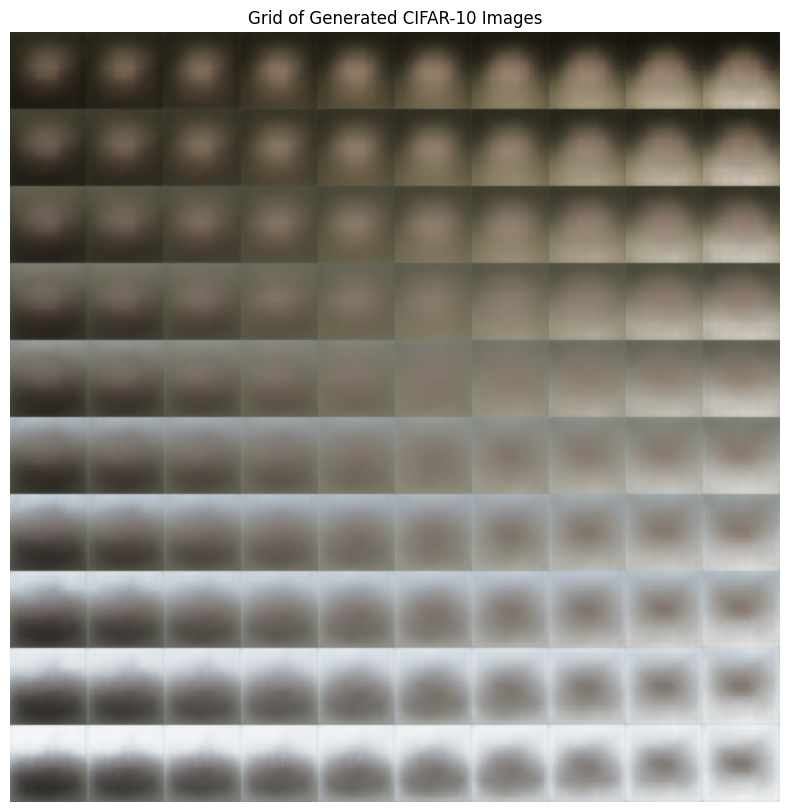

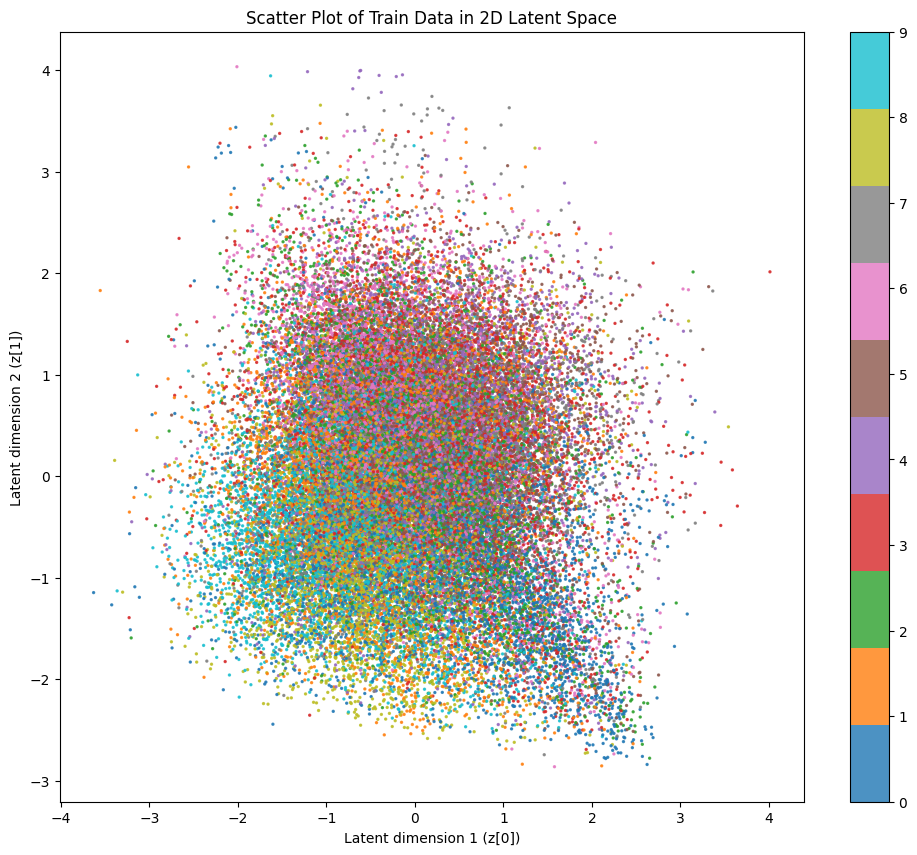

In [7]:
# --- 1. Grid of generated images (Modified for RGB CIFAR-10) ---
n = 10
img_dim = 32 # CIFAR-10 spatial dimension
scale = 2.0

# Initialize an empty array for the grid. Add 3 for RGB channels.
figure = np.zeros((img_dim * n, img_dim * n, 3))

# Linearly spaced coordinates for 2D latent space
grid_x = np.linspace(-scale, scale, n)
grid_y = np.linspace(-scale, scale, n)[::-1]

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        # Sample a point from the 2D latent space
        z_sample = np.array([[xi, yi]])
        x_decoded = saved_vae_decoder.predict(z_sample, verbose=0)

        # Reshape to image dimensions
        digit = x_decoded[0].reshape(img_dim, img_dim, 3)

        # Place the generated image in the grid
        figure[
            i * img_dim : (i + 1) * img_dim,
            j * img_dim : (j + 1) * img_dim,
            :
        ] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure)
plt.axis('off')
plt.title("Grid of Generated CIFAR-10 Images")
plt.savefig("vae_grid.png", dpi=300, bbox_inches='tight')
plt.show()

# --- 2. Scatter Plot of Latent Space ---
plt.figure(figsize=(12, 10))
scatter = plt.scatter(
    saved_z_mean_train[:, 0],
    saved_z_mean_train[:, 1],
    c=y_train,
    cmap='tab10',
    s=2,
    alpha=0.8
)
plt.colorbar(scatter, ticks=range(10))
plt.title("Scatter Plot of Train Data in 2D Latent Space")
plt.xlabel("Latent dimension 1 (z[0])")
plt.ylabel("Latent dimension 2 (z[1])")
plt.savefig("vae_scatter.png", dpi=300, bbox_inches='tight')
plt.show()